## Fantasy NBA Analysis Project

#### 1. Problem Statement -
 - <u>Objective:</u> Objective: Predict individual NBA player statistics (PTS, REB, AST, STL, BLK, 3PM, FG%, FT%, TO) for the upcoming season to support fantasy basketball decisions in a 9-category Head-to-Head (H2H) league format.
 - <u>Why it matters:</u> In fantasy basketball, especially in the 9-cat H2H format, success depends on forecasting player performance across multiple statistical categories, not just points.
 - <u>Practical Outcome:</u> A system that predicts performance in each category per player and his total outcome, enabling data-driven team-building recommendations.
#### 2. Data Collection -
 - NBA API - Used to get updated data (e.g., average stats).
 - Kaggle - "NBA - Player stats - Season 24/25" (per game stats until all-star break), "NBA Players Stats 23/24", "2022-2023 NBA Player Stats"
 - Basketball Reference - Manually downloaded per-game and total stats for seasons 2020-2021 ,2021-2022 ,2022-2023, 2023-2024, and 2024-2025. (Consistency in date formatting.)
#### 3. Method -
 - Measuring player performance based on the Z-score (a common ranking system in the 9-cat H2H format).
 - **Formula** - per-category Z-score is calculated as $Z = (\text{value} - \text{mean}) / \text{std}$. For Turnovers (TOV), the sign is flipped: $Z = (\text{mean} - \text{TOV}) / \text{std}$ (as higher TOV is detrimental).
 - For the first task, I will predict the total Z-score across a season for fantasy players. The model will be trained on data from the 2021-2024 seasons, tested on the 2024-2025 season, and used to provide predictions for the upcoming 2025-2026 season.
 - **Regression models** -
     - OLS (ordinary least squares) by statmodels - the foundational technique of linear regression. It works by finding the line (or hyperplane) that minimizes the sum of the squared vertical distances (residuals) between the data points and the line.
     - Linear Regression - the general model that assumes a linear relationship between the input features and the target variable, most often using the OLS method to find the best-fitting coefficients.
     - Ridge Regression - a variation of linear regression that introduces L2 regularization. This technique adds a penalty to the OLS loss function based on the square of the coefficient magnitudes. Its primary purpose is to shrink the coefficients towards zero, which helps prevent overfitting and improves stability in cases where features are highly correlated (multicollinearity).
     - Linear Regression + PCA - a two-stage modeling approach. PCA is first applied to the data to reduce its dimensionality by transforming the original features into a smaller, uncorrelated set of components. Linear Regression is then performed on these new components.
     - Random Forest Regressor - a powerful ensemble method. It constructs multiple independent Decision Trees during training and computes the final prediction by taking the average of the individual tree predictions. This averaging process makes the model robust to outliers and generally highly accurate.
     - XGBoost Regressor (Extreme Gradient Boosting) - a state-of-the-art Gradient Boosting ensemble technique. It builds trees sequentially, where each new tree is designed to correct the errors left by the previous ensemble of trees. It is well-regarded for its high efficiency and top-tier predictive performance across many datasets.
 - **Evaluation metrics** -
   * R-squared - a fundamental metric that represents the proportion of the variance in the target variable that is explained by the features in the model. A score of 1.0 indicates a perfect fit, while 0.0 means the model performs no better than simply predicting the mean of the target variable.
   * RMSE (root mean squared error) - measures the square root of the average of the squared errors. Because errors are squared before being averaged, this metric is highly sensitive to large errors (outliers), making it the preferred choice when you need to severely penalize poor predictions.
   * MAE (mean absoulte error) - measures the average of the absolute differences between the model's predictions and the actual values. It is less sensitive to outliers than RMSE and provides an error value that is in the same units as the target variable, making it very interpretable.
   * Mean Absolute Percentage Error (MAPE) - calculates the average of the absolute percentage errors. This is a scale-independent metric that expresses the model's accuracy as a percentage of the actual value, providing a highly intuitive measure for business interpretation.
   * Adjusted R-squared - improves upon $R^2$ by penalizing the metric when new features are added that do not significantly contribute to the model's predictive power. This makes it a more reliable metric for comparing models that contain different numbers of features.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle
import time
from nba_api.stats.endpoints import playergamelog, leaguegamelog, playercareerstats, commonplayerinfo
from nba_api.stats.static import players
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV, LinearRegression, Ridge

import sys
sys.path.append(os.getcwd())
import utils


print("✅ All libraries are working!")


✅ All libraries are working!


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eduardopalmieri/nba-player-stats-season-2425")
print("Path to dataset files:", path)

path2 = kagglehub.dataset_download("bryanchungweather/nba-player-stats-dataset-for-the-2023-2024")
print("Path to dataset files:", path2)

path3 = kagglehub.dataset_download("orkunaktas/nba-players-stats-2324")
print("Path to dataset files:", path3)

Path to dataset files: C:\Users\maors\.cache\kagglehub\datasets\eduardopalmieri\nba-player-stats-season-2425\versions\37
Path to dataset files: C:\Users\maors\.cache\kagglehub\datasets\bryanchungweather\nba-player-stats-dataset-for-the-2023-2024\versions\14
Path to dataset files: C:\Users\maors\.cache\kagglehub\datasets\orkunaktas\nba-players-stats-2324\versions\1


**I used the functions 'get_player_stats_from_api' in the utils files to extract the relevant data (avg stats from seasons 21,22,23,24,25) for my project from NBA API and to save it as a CSV on my computer. Total number of players ~500**

In [4]:
# --- EXECUTION EXAMPLE ---
# updated_nba_stats = utils.get_player_stats_from_api('nba_5seasons_final_with_nulls.csv')
# print(updated_nba_stats.head())

**Z-score calculation for all 9 categories and aggregation**

In [5]:
df = pd.read_csv("../data/nba_player_stats_from_2020-21_to_2024-25.csv")

In [6]:
# --- Step 1: Map columns ---
pts_col = "PTS"
trb_col = "REB"
ast_col = "AST"
stl_col = "STL"
blk_col = "BLK"
threepm_col = "FG3M"
fg_pct_col = "FG_PCT"
ft_pct_col = "FT_PCT"
tov_col = "TOV"
gp_col = "GP"
fgm_col = "FGM"
fga_col = "FGA"
ftm_col = "FTM"
fta_col = "FTA"
min_col = "MIN"
oreb_col = "OREB"
dreb_col = "DREB"
pf_col = "PF"
fg3a_col = "FG3A"

for col in [pts_col, trb_col, ast_col, stl_col, blk_col, threepm_col, tov_col, fgm_col, ftm_col, fga_col, fta_col, min_col, oreb_col, dreb_col, pf_col, fg3a_col]:
    df[col] = utils.per_game_if_needed(df[col], df[gp_col])

# Ensure FG% and FT% are fractions [0,1]
if df[fg_pct_col].max() > 1.5:
    df[fg_pct_col] = df[fg_pct_col] / 100
if df[ft_pct_col].max() > 1.5:
    df[ft_pct_col] = df[ft_pct_col] / 100

# This reduces noise for players with very few attempts.
m_fg, m_ft = 100, 50  # shrinkage strength (hyperparameters)
league_fg_mean = df[fg_pct_col].mean()
league_ft_mean = df[ft_pct_col].mean()

df["fg_shrunk"] = (df[fg_pct_col]*df[fga_col] + m_fg*league_fg_mean) / (df[fga_col] + m_fg)
df["ft_shrunk"] = (df[ft_pct_col]*df[fta_col] + m_ft*league_ft_mean) / (df[fta_col] + m_ft)

cats = {
    "PTS": pts_col,
    "REB": trb_col,
    "AST": ast_col,
    "STL": stl_col,
    "BLK": blk_col,
    "FG3M": threepm_col,
    "FG%": "fg_shrunk",
    "FT%": "ft_shrunk",
    "TOV": tov_col,
}

#Compute Z-score
for name, col in cats.items():
    def zscore(x):
        mean, std = x.mean(), x.std(ddof=0)
        if std == 0:
            return (x - mean)  # avoid div/0, all values same
        if name == "TOV":  # turnovers - lower is better
            return (mean - x) / std
        else:
            return (x - mean) / std

    df[f"z_{name}"] = df.groupby("SEASON_ID")[col].transform(zscore)

z_cols = [f"z_{c}" for c in cats.keys()]
df["fantasy_z_9cat"] = df[z_cols].sum(axis=1)

#Save data
#df.to_csv("nba_player_stats_from_2020-21_to_2024-25_with_z_12.csv", index=False)

# Show top 10
print(df[["PLAYER_NAME", "SEASON_ID", "fantasy_z_9cat"] + z_cols].sort_values("fantasy_z_9cat", ascending=False).head(10))


                  PLAYER_NAME SEASON_ID  fantasy_z_9cat     z_PTS     z_REB  \
1229              Joel Embiid   2023-24       17.604072  3.656983  3.010286   
1887             Nikola Jokić   2024-25       16.588658  2.751711  3.567014   
2177  Shai Gilgeous-Alexander   2024-25       15.557988  3.202402  0.370775   
2176  Shai Gilgeous-Alexander   2023-24       15.477930  2.974290  0.723238   
1228              Joel Embiid   2022-23       15.127221  3.400378  2.720204   
1884             Nikola Jokić   2021-22       14.980551  2.821513  4.128773   
98              Anthony Davis   2023-24       14.884312  2.184145  3.684492   
1886             Nikola Jokić   2023-24       14.825487  2.435531  3.563606   
1469             Kevin Durant   2022-23       14.188789  2.898007  1.232113   
1885             Nikola Jokić   2022-23       14.154193  2.125983  3.452237   

         z_AST     z_STL     z_BLK    z_FG3M     z_FG%     z_FT%     z_TOV  
1229  1.685541  1.281003  3.143920  0.304156  2.32602

**Originally I added with another data frame the position of each player. Instead of running the code I will just add here the finalize dataframe**

In [7]:
# --- Execution example for adding position to existing data---
#updated_data_with_pos = utils.add_position_to_existing_data('nba_player_stats_from_2020-21_to_2024-25.csv')
#print(updated_data_with_pos.head())

In [8]:
#Loading the final data frame
df_first = pd.read_csv("../data/nba_player_stats_from_2020-21_to_2024-25_with_z.csv")
df_first.rename(columns = {'FG_PCT':'FG%', 'FT_PCT':'FT%'},inplace = True)
df_first.drop(columns = ['Rk', 'TEAM_ABBREVIATION', "3PA", "3P%", "2PA", "2P%", "eFG%", "2P"], inplace = True)
df.dropna(subset = "PTS", inplace = True)
#print("Sample from the model's dataframe \n")
df_first = df_first.drop_duplicates(subset=['PLAYER_NAME', 'SEASON_ID'], keep='first')

#filtering only on player who played 50 games or more across the last 5 seasons
player_total_gp = df_first.groupby('PLAYER_NAME')['GP'].sum().reset_index(name='Total_Career_GP_in_Range')
# Merge the total back into the merged DataFrame
df_first = df_first.merge(player_total_gp, on='PLAYER_NAME', how='left')
# Filter for players who meet the total GP minimum
df = df_first[df_first['Total_Career_GP_in_Range'] >= 50].copy()
df = df[df['MIN'] >= 6].copy()
# Drop the temporary column before saving
df = df.drop(columns=['Total_Career_GP_in_Range'])

print(df.sample(6))


            PLAYER_NAME  PLAYER_ID SEASON_ID  LEAGUE_ID       TEAM_ID  \
1885         Zeke Nnaji  1630192.0   2023-24        0.0  1.610613e+09   
1678       Shake Milton  1629003.0   2023-24        0.0  0.000000e+00   
1826  Tyrese Haliburton  1630169.0   2023-24        0.0  1.610613e+09   
1939       Jared Butler        NaN   2023-24        NaN           NaN   
496       Devin Vassell  1630170.0   2023-24        0.0  1.610613e+09   
1291      Malik Beasley  1627736.0   2020-21        0.0  1.610613e+09   

      PLAYER_AGE    GP    GS        MIN       FGM  ...     z_REB     z_AST  \
1885        23.0  58.0   0.0   9.931034  1.189655  ... -0.704380 -0.885866   
1678        27.0  48.0   0.0  12.104167  1.645833  ... -0.955747 -0.519214   
1826        24.0  69.0  68.0  32.231884  7.246377  ...  0.018967  4.547072   
1939        23.0  40.0   0.0  14.200000  2.500000  ... -0.981506  0.504697   
496         23.0  68.0  62.0  33.058824  7.323529  ... -0.017837  0.963372   
1291        24.0  37

## EDA
---
**Exploring the different distributions of the relevant features for 9-CAT H2H format**

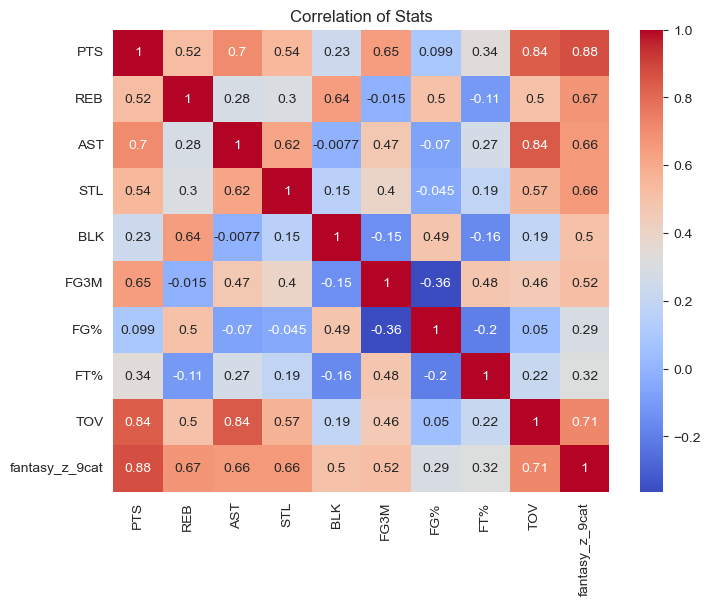

In [9]:
stats_cols = ["PLAYER_NAME", "SEASON_ID", "GP", "PTS", "REB", "AST", "STL", "BLK", "FG3M", "FG%", "FT%", "TOV", "fantasy_z_9cat"]
df_stats = df[stats_cols].copy()

plt.figure(figsize=(8,6))
sns.heatmap(df_stats.drop(columns=["PLAYER_NAME", "SEASON_ID", "GP"], inplace=False).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Stats")
plt.show()

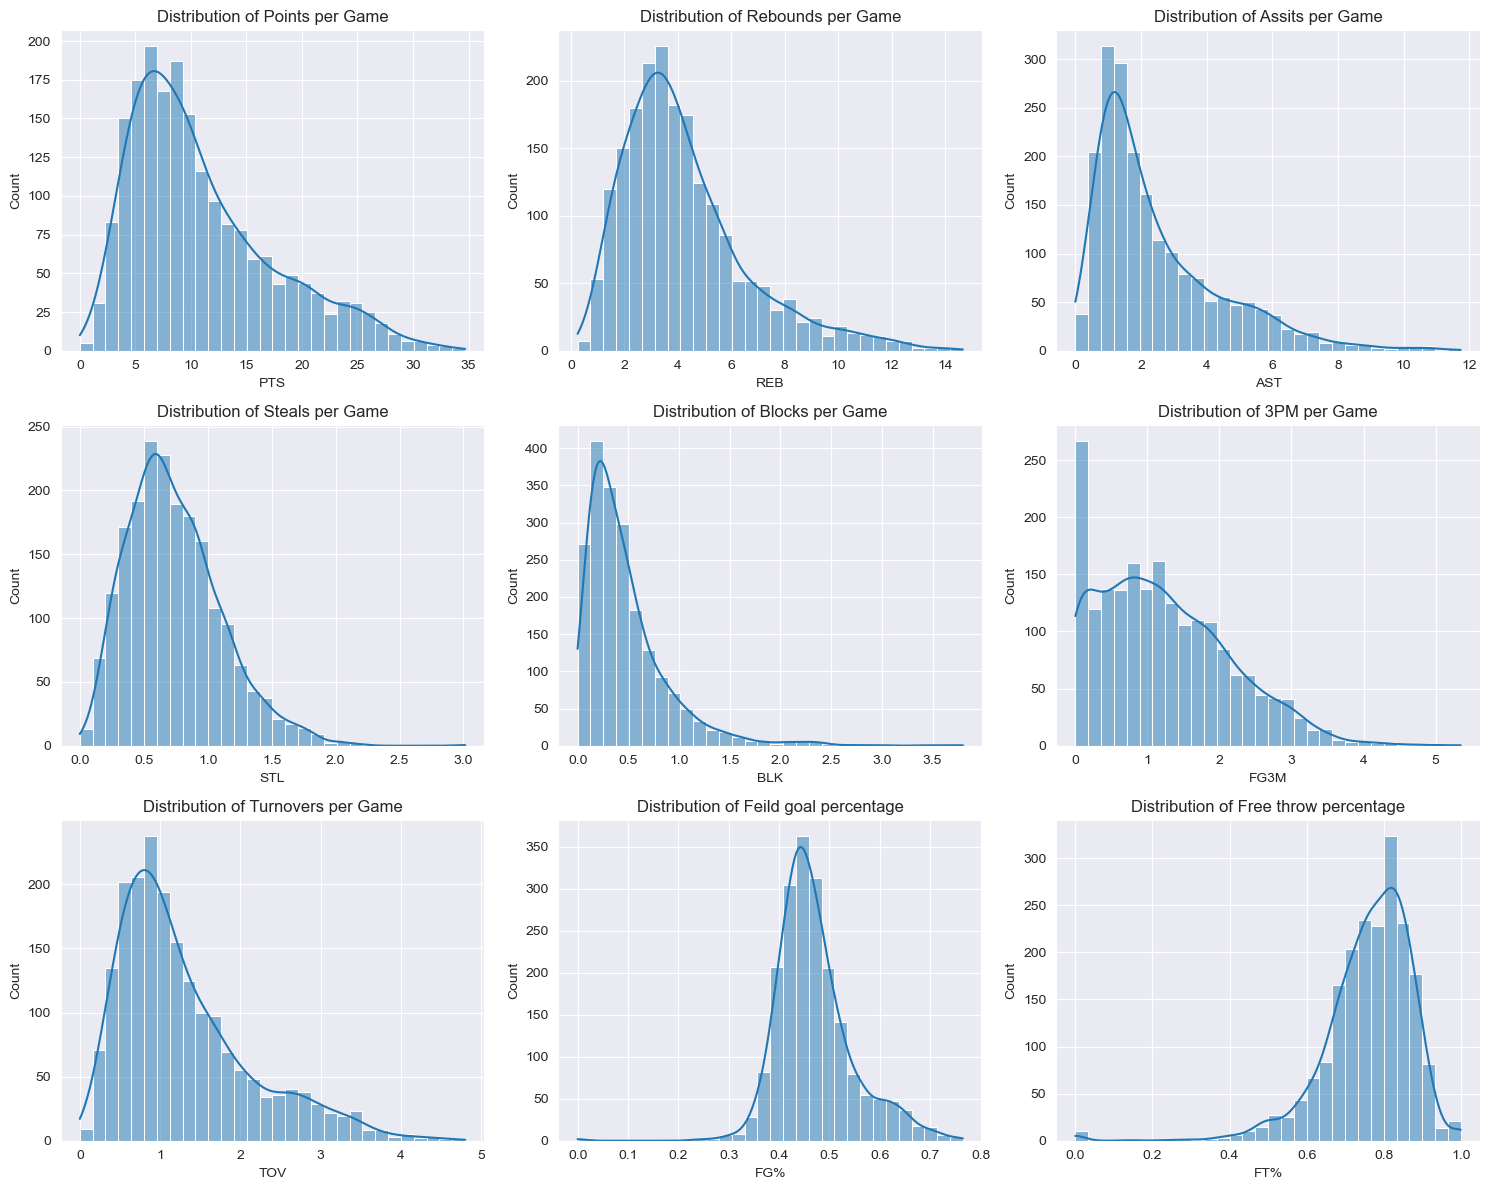

In [10]:
fig, axs = plt.subplots(3,3, figsize=(15, 12))

#Histogram of Points
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["PTS"], bins=30, kde=True, ax=axs[0,0])
axs[0,0].set_title("Distribution of Points per Game")

#Histogram of Rebounds
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["REB"], bins=30, kde=True, ax=axs[0,1])
axs[0,1].set_title("Distribution of Rebounds per Game")

#Histogram of Assits
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["AST"], bins=30, kde=True, ax=axs[0,2])
axs[0,2].set_title("Distribution of Assits per Game")

#Histogram of Steals
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["STL"], bins=30, kde=True, ax=axs[1,0])
axs[1,0].set_title("Distribution of Steals per Game")

#Histogram of Blocks
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["BLK"], bins=30, kde=True, ax=axs[1,1])
axs[1,1].set_title("Distribution of Blocks per Game")

#Histogram of 3PM
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["FG3M"], bins=30, kde=True, ax=axs[1,2])
axs[1,2].set_title("Distribution of 3PM per Game")

#Histogram of Turnovers
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["TOV"], bins=30, kde=True, ax=axs[2,0])
axs[2,0].set_title("Distribution of Turnovers per Game")

#Histogram of Feild Goal percentage
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["FG%"], bins=30, kde=True, ax=axs[2,1])
axs[2,1].set_title("Distribution of Feild goal percentage")

#Histogram of Free throw percentage
#plt.figure(figsize=(6,4))
sns.histplot(df_stats["FT%"], bins=30, kde=True, ax=axs[2,2])
axs[2,2].set_title("Distribution of Free throw percentage")

plt.tight_layout()
plt.show()

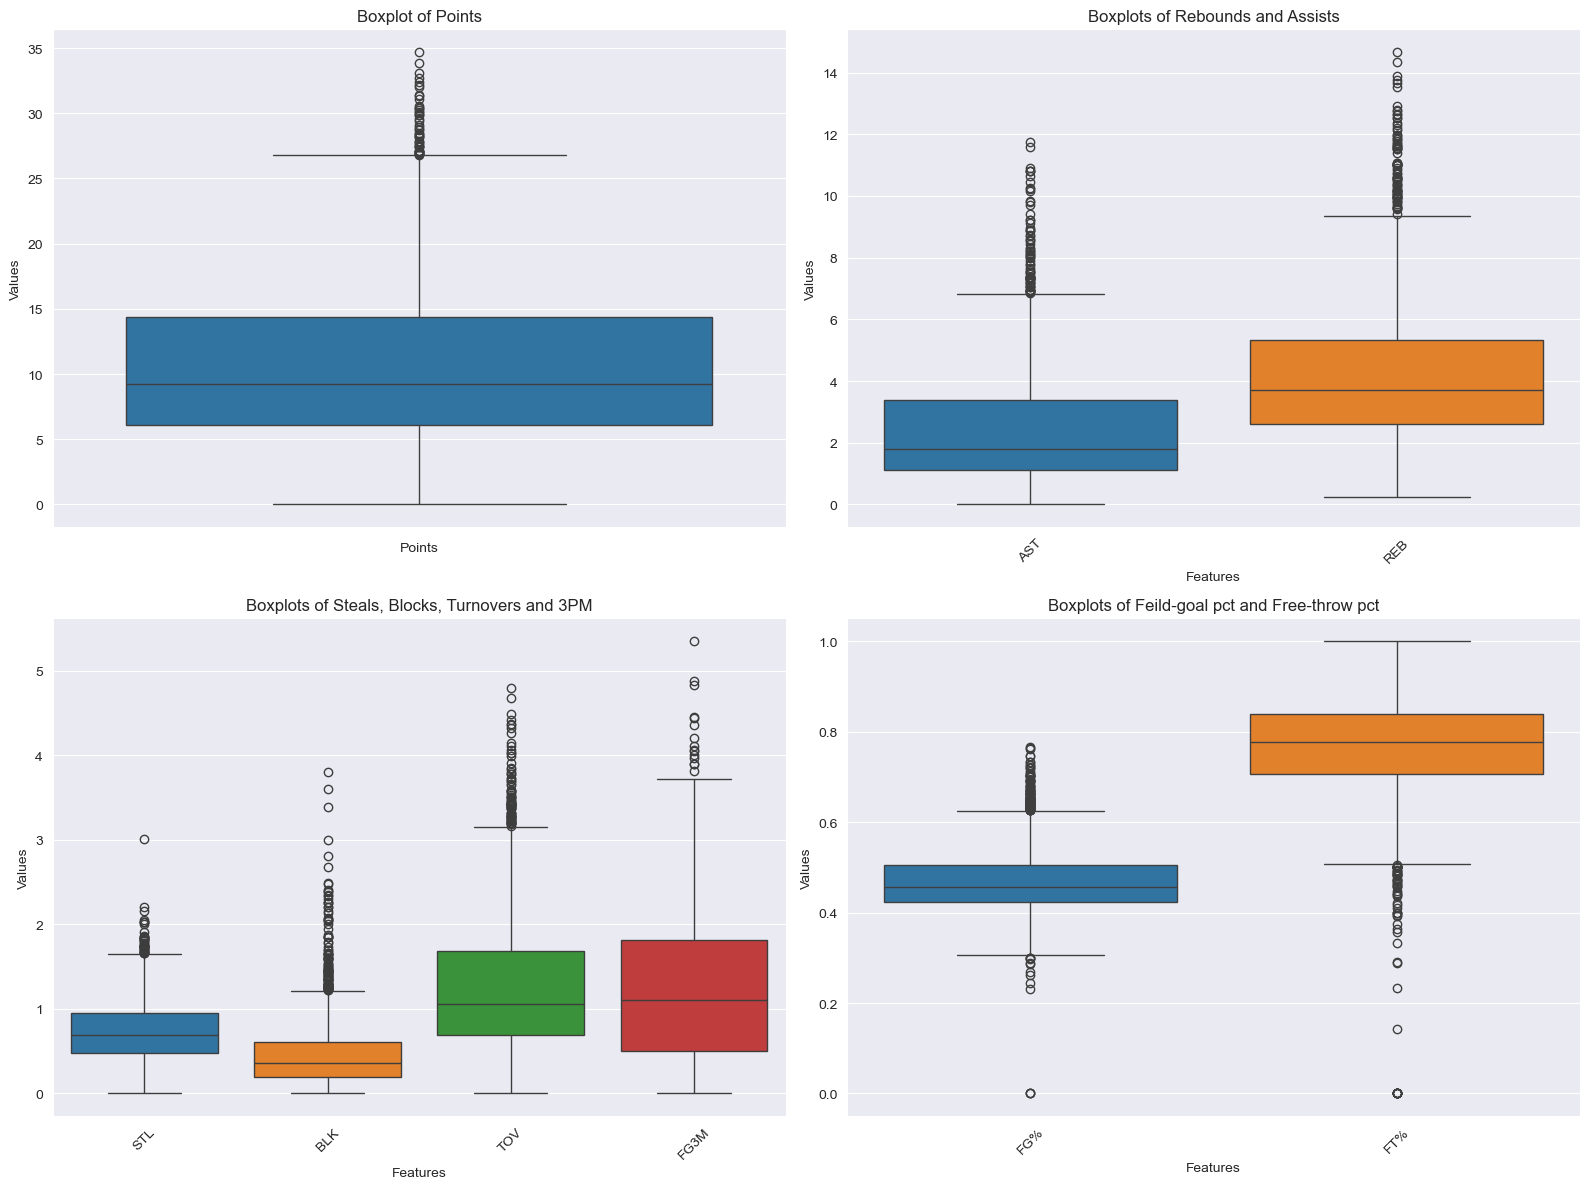

League average points: 10.953886768163883 Median points 9.2
League average rebounds: 4.246218887704603
League average asstits: 2.4824804127840165
League average steals: 0.7406439041942338
League average blocks: 0.4730731680991401
League average 3-points made: 1.2250292073940314
League average turnovers: 1.2919964135619626
League median field-goal percentage: 0.4701896813353566
League median field-goal percentage: 0.7609468892261002


In [11]:
high_value_features, medium_value_features, low_value_feaures = ["AST", "REB"], ["STL", "BLK", "TOV", "FG3M"], ["FG%", "FT%"]
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
#Points boxplots
sns.boxplot(data=df["PTS"], ax=axs[0, 0])
axs[0,0].set_title('Boxplot of Points')
axs[0,0].set_xlabel('Points')
axs[0,0].set_ylabel('Values')
axs[0,0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for clarity

#Rebounds and Assists boxplots
sns.boxplot(data=df[high_value_features], ax = axs[0,1])
axs[0,1].set_title('Boxplots of Rebounds and Assists')
axs[0,1].set_xlabel('Features')
axs[0,1].set_ylabel('Values')
axs[0,1].tick_params(axis='x', rotation=45)

#Steals, Blocks, Turnovers, 3-point made boxplots
sns.boxplot(data=df[medium_value_features], ax = axs[1,0])
axs[1,0].set_title('Boxplots of Steals, Blocks, Turnovers and 3PM')
axs[1,0].set_xlabel('Features')
axs[1,0].set_ylabel('Values')
axs[1,0].tick_params(axis='x', rotation=45)

#Feild goal percentage and free throw percentage boxplots
sns.boxplot(data=df[low_value_feaures], ax = axs[1,1])
axs[1,1].set_title('Boxplots of Feild-goal pct and Free-throw pct')
axs[1,1].set_xlabel('Features')
axs[1,1].set_ylabel('Values')
axs[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("League average points:", df_stats["PTS"].mean(), "Median points", df_stats["PTS"].median())
print("League average rebounds:", df_stats["REB"].mean())
print("League average asstits:", df_stats["AST"].mean())
print("League average steals:", df_stats["STL"].mean())
print("League average blocks:", df_stats["BLK"].mean())
print("League average 3-points made:", df_stats["FG3M"].mean())
print("League average turnovers:", df_stats["TOV"].mean())
print("League median field-goal percentage:", df_stats["FG%"].mean())
print("League median field-goal percentage:", df_stats["FT%"].mean())

### Initial EDA conclusions

**The analysis of the data reveals several key correlations and distribution patterns among the features.**

---
* A **strong positive correlation** is observed among points, assists, and turnovers. This suggests that players who are primary scorers and ball-handlers tend to have more opportunities for assists but also assume greater risk, which can lead to a higher frequency of turnovers.
* Rebounds and blocks also exhibit a **high positive correlation**. This is a logical relationship, as taller players, who typically play frontcourt positions, are more likely to achieve higher numbers in both categories. Furthermore, these two categories show a **positive correlation with field goal percentage**. This can be attributed to frontcourt players generally taking shots from closer to the basket, which results in a higher shooting percentage compared to players who shoot from a distance.
* Field goal percentage appears to follow a **t-distribution centered around the 47% mark** (I determined it is  a t-distribution and not normal because of the wider tails). This indicates that most players' field goal percentages cluster near this average, with fewer players having extremely high or low percentages. On the other hand, Free throw percentage appears to follow a **t-distribution centered around the 75% mark** but the tails are much wider than those of the eild goal percentage stat. It means that large amount of players is considered as outliers in the FT% category.
* The distributions of points, rebounds, and assists are **right-skewed**, indicating a **heavy-tailed distribution**. This distribution pattern confirms the presence of outliers and extreme values that are significantly greater than the majority of the data. Consistent with this skew, the **mean value for each of these features is higher than the median**, a direct result of the influence of these high-value outliers pulling the mean upwards.
* Lastly, according to the correlation heatmap, the feature **Points** has a the strongest correlation with the total Z-score, while the feature **FG percentage** has the lowest correlation (though still solid) among all features.

**Exploring the different connections between the 9cat features**

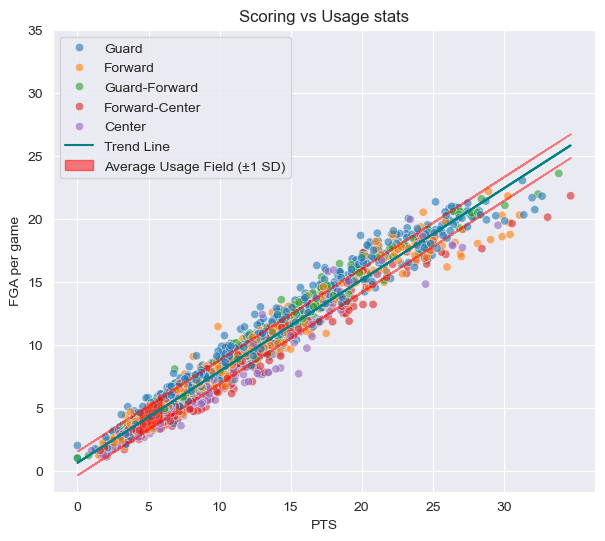

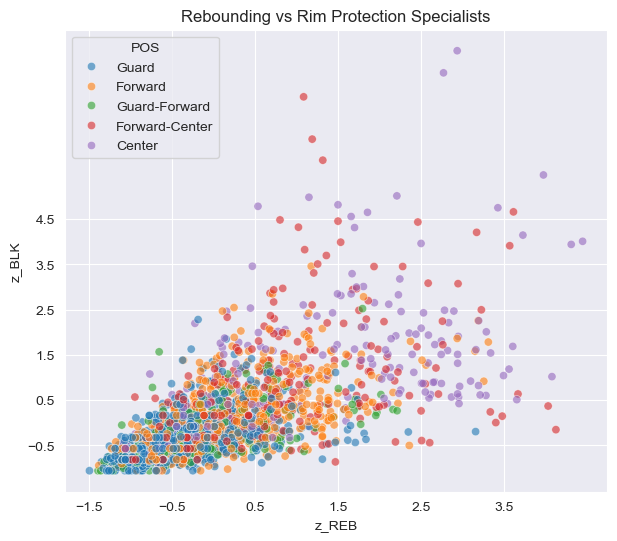

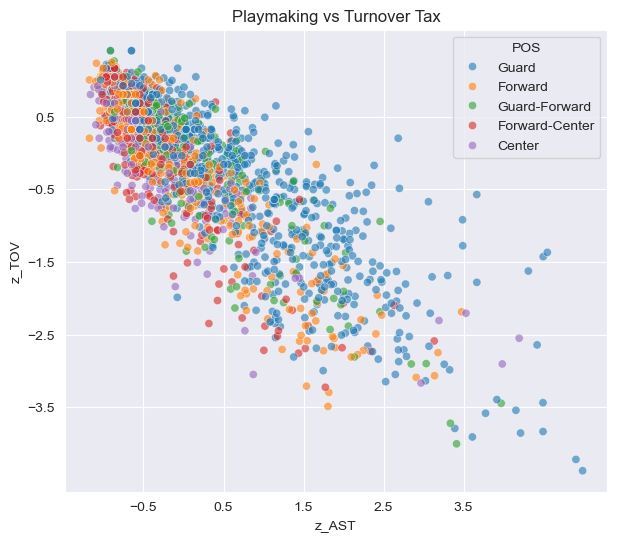

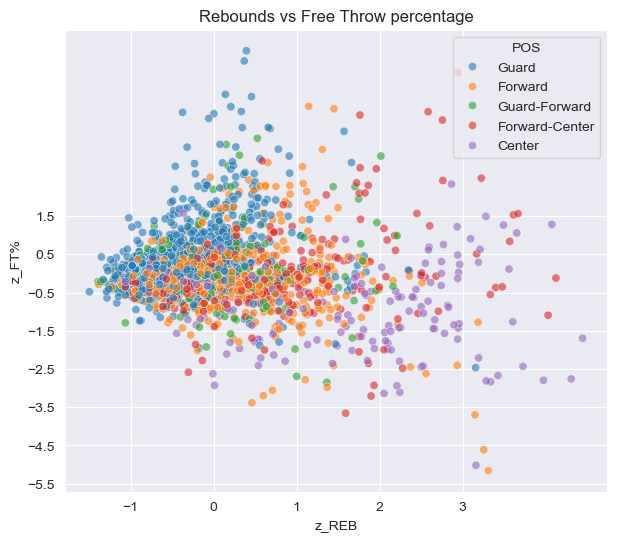

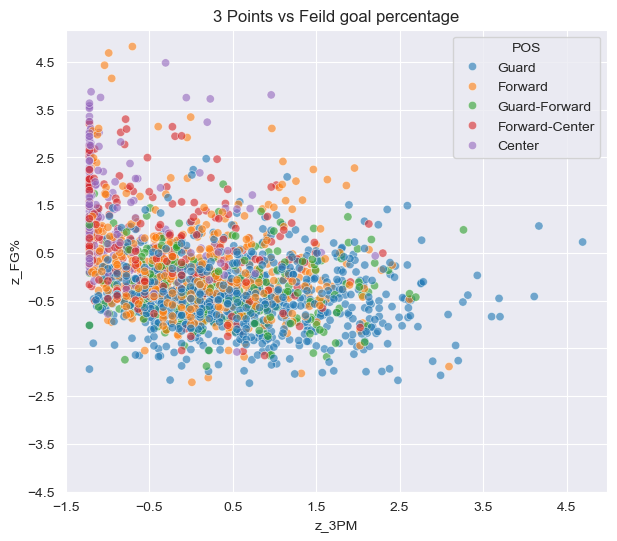

In [12]:
df["Total_PTS"] = df["PTS"]*df["GP"]
# Example 1: Scoring vs Assists
plt.figure(figsize=(7,6))
sns.scatterplot(x="PTS", y="FGA", hue = "POS", data=df, alpha=0.6)
plt.title("Scoring vs Usage stats")
plt.xlabel("PTS")
plt.ylabel("FGA per game")
model = LinearRegression()
X = df[['PTS']]
y = df['FGA']
model.fit(X, y)

# Plot the trend line
plt.plot(X, model.predict(X), color='teal', linestyle='-', linewidth=1.5, label='Trend Line')

# Add a filled area for the average usage field
# Calculate residuals and standard deviation
residuals = y - model.predict(X)
std_dev = np.std(residuals)
plt.fill_between(
    X['PTS'],
    model.predict(X) - std_dev,
    model.predict(X) + std_dev,
    color='red',
    alpha=0.5,
    label='Average Usage Field (±1 SD)'
)
plt.legend()
tick_locations = np.arange(0,35,5)
tick_y_locations = np.arange(0,40,5)
plt.xticks(tick_locations)
plt.yticks(tick_y_locations)
plt.grid(True)
plt.show()

# Example 2: Rebounding vs Blocking
plt.figure(figsize=(7,6))
sns.scatterplot(x="z_REB", y="z_BLK",hue = "POS", data=df, alpha=0.6)
plt.title("Rebounding vs Rim Protection Specialists")
plt.xlabel("z_REB")
plt.ylabel("z_BLK")
tick_locations = np.arange(-1.5,4,1)
tick_y_locations = np.arange(-0.5,5.5,1)
plt.xticks(tick_locations)
plt.yticks(tick_y_locations)
plt.grid(True)
plt.show()

# Example 3: Assists vs Turnovers (risk/reward guards)
plt.figure(figsize=(7,6))
sns.scatterplot(x="z_AST", y="z_TOV", hue = "POS", data=df, alpha=0.6)
plt.title("Playmaking vs Turnover Tax")
plt.xlabel("z_AST")
plt.ylabel("z_TOV")
tick_locations = np.arange(-0.5, 4, 1)
tick_y_locations = np.arange(-3.5,1.5,1)
plt.xticks(tick_locations)
plt.yticks(tick_y_locations)
plt.grid(True)
plt.show()

# Example 4: Rebounds vs Free Throw percentage
plt.figure(figsize=(7,6))
sns.scatterplot(x="z_REB", y="z_FT%", hue = "POS", data=df, alpha=0.6)
plt.title("Rebounds vs Free Throw percentage")
plt.xlabel("z_REB")
plt.ylabel("z_FT%")
tick_locations = np.arange(-1, 4, 1)
tick_y_locations = np.arange(-5.5,2.5,1)
plt.xticks(tick_locations)
plt.yticks(tick_y_locations)
plt.grid(True)
plt.show()

# Example 5: 3 Points vs Feild goal percentage
plt.figure(figsize=(7,6))
sns.scatterplot(x="z_FG3M", y="z_FG%", hue = "POS", data=df, alpha=0.6)
plt.title("3 Points vs Feild goal percentage")
plt.xlabel("z_3PM")
plt.ylabel("z_FG%")
tick_locations = np.arange(-1.5, 5, 1)
tick_y_locations = np.arange(-4.5,5.5,1)
plt.xticks(tick_locations)
plt.yticks(tick_y_locations)
plt.grid(True)
plt.show()


**Correlation between key stats to total Z-score (fantasy_z_9cat)** - Testing how well the stats predict the fantasy rank of a player.

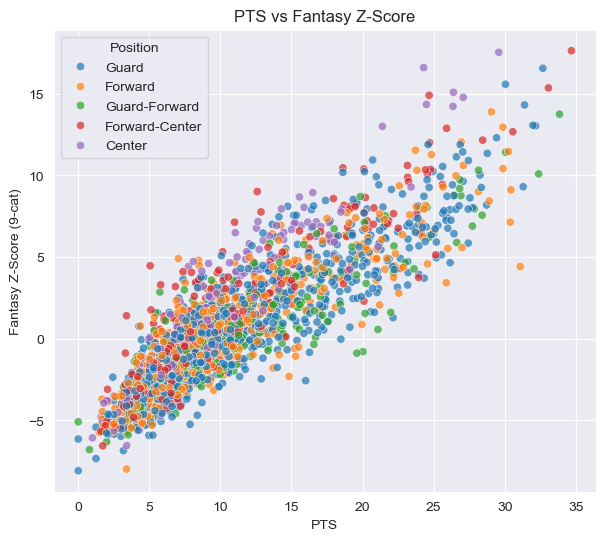

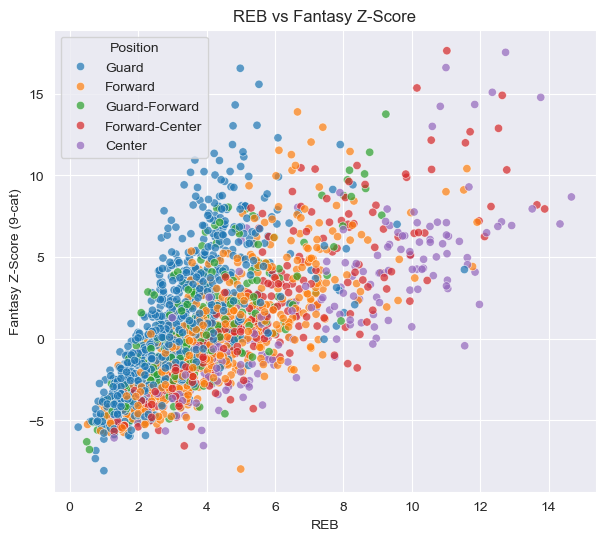

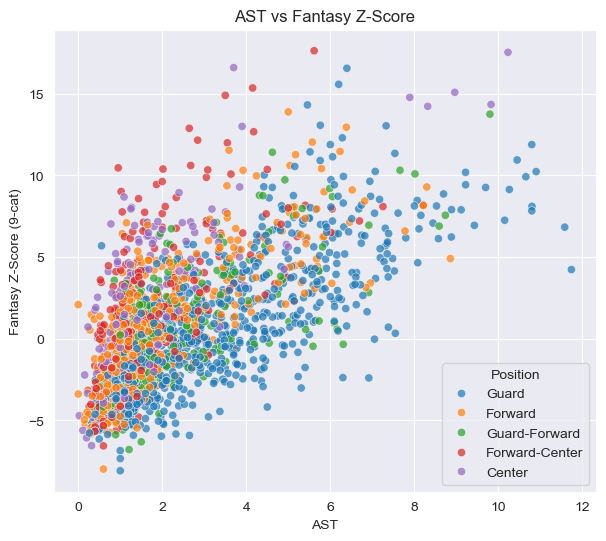

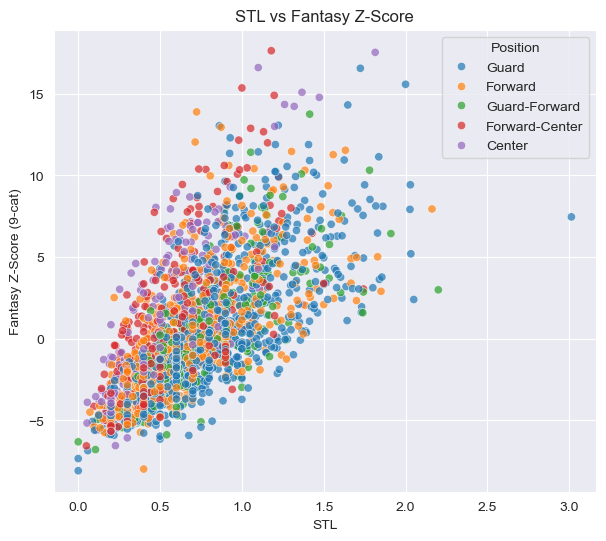

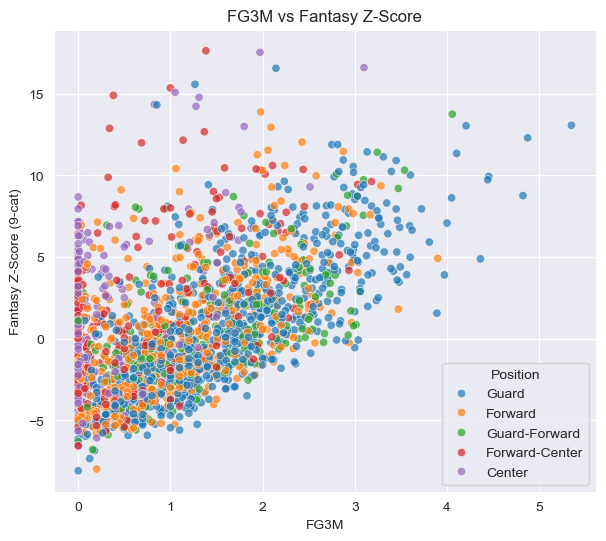

In [13]:
key_stats = ['PTS', 'REB', 'AST', 'STL', 'FG3M']

for stat in key_stats:
    if stat in df.columns:
        plt.figure(figsize=(7,6))
        sns.scatterplot(x=df[stat], y=df['fantasy_z_9cat'], hue=df['POS'], alpha=0.7)
        plt.title(f"{stat} vs Fantasy Z-Score")
        plt.xlabel(stat)
        plt.ylabel("Fantasy Z-Score (9-cat)")
        plt.legend(title="Position")
        plt.show()

**Exploring the cirrelations between the seasons stats, to check player's stability**
Using MAE which Measures how much the fantasy score changed on average from one season to the next.
The last output is the MAE between 2023-24 to 2024-25.

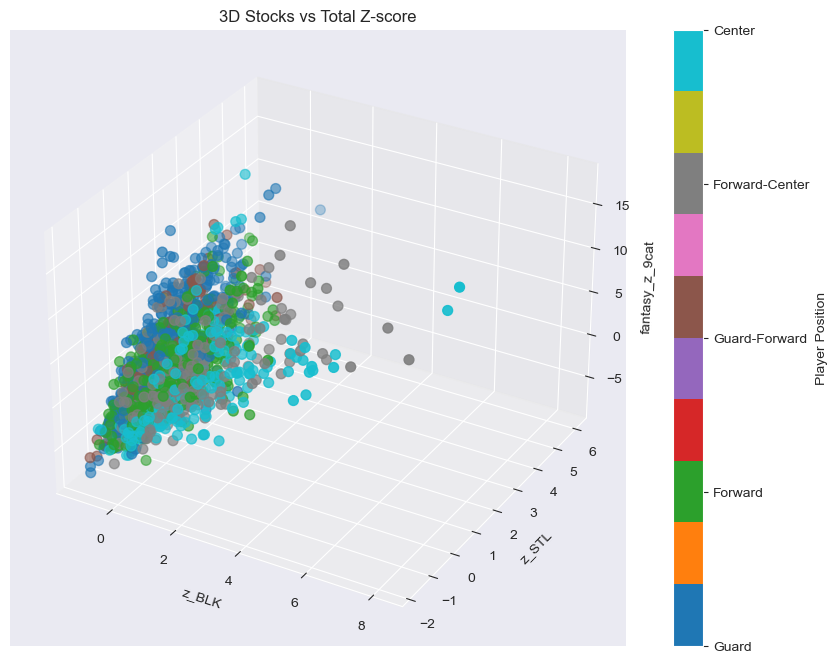

In [14]:
#Example 2: 3D- scatter plot to show the connection between Rebounds, Blocks and Free Throw percentage
positions = df['POS'].unique()
pos_to_index = {pos: i for i, pos in enumerate(positions)}
color_indices = df['POS'].map(pos_to_index)
fig = px.scatter_3d(
    df,
    x='z_STL',
    y='z_BLK',
    z='fantasy_z_9cat',
    color='POS',
    hover_data={'PLAYER_NAME': True, 'z_STL': ':.2f', 'z_BLK': ':.2f', 'fantasy_z_9cat': ':.2f'}
)
# Customize the plot layout
fig.update_layout(
    title='Player Steals and Blocks vs. Fantasy Z-Score',
    scene=dict(xaxis_title='Steals', yaxis_title='Blocks', zaxis_title='Total Z-Score', aspectmode='data', camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.5))), width=700, height=600)
fig.show()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df["z_BLK"], df['z_STL'], df['fantasy_z_9cat'], c=color_indices, cmap='tab10', s=50)
cbar = plt.colorbar(sc, ticks=range(len(positions)))
cbar.ax.set_yticklabels(positions)
cbar.set_label('Player Position')
ax.set_xlabel('z_BLK')
ax.set_ylabel('z_STL')
ax.set_zlabel('fantasy_z_9cat')
ax.set_title('3D Stocks vs Total Z-score')
plt.show()


Year-to-year fantasy z-score correlation:
SEASON_ID   2020-21   2021-22   2022-23   2023-24   2024-25
SEASON_ID                                                  
2020-21    1.000000  0.782966  0.725782  0.679224  0.636100
2021-22    0.782966  1.000000  0.828416  0.800936  0.706001
2022-23    0.725782  0.828416  1.000000  0.857705  0.761919
2023-24    0.679224  0.800936  0.857705  1.000000  0.846091
2024-25    0.636100  0.706001  0.761919  0.846091  1.000000


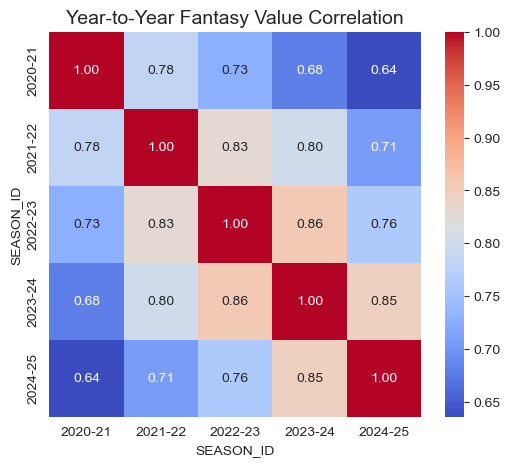

In [15]:
if 'PLAYER_NAME' in df.columns and 'SEASON_ID' in df.columns:
    pivot = df.pivot_table(index='PLAYER_NAME', columns='SEASON_ID', values='fantasy_z_9cat')
    # Compute correlation between seasons
    corr_matrix = pivot.corr()
    print("Year-to-year fantasy z-score correlation:")
    print(corr_matrix)

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Year-to-Year Fantasy Value Correlation", fontsize=14)
    plt.show()

    #print(pivot.head())

### Additional EDA Conclusions
**Based on the scatter plots and specialist analysis, here are the key conclusions:**

-----
#### Player Performance and Efficiency
  * **Scoring Efficiency:** Frontcourt players, especially centers, are the most efficient scorers.
  * **Passing Efficiency:** Players in the upper-right quadrant of the Assists vs. Turnovers plot are efficient passers. A select group of elite players with a Z-score above 1.5 in assists and a turnover Z-score of -0.5 or better are particularly valuable. These players significantly boost a team's assist numbers without negatively impacting turnovers, making them ideal for teams built around big men. *(Note: Be mindful of outliers like Jeff Dowtin Jr. and Keon Ellis, whose stats may be skewed due to a small sample size of games.)*
  * **Frontcourt Versatility:** Some frontcourt players contribute positively to both rebounds and free-throw percentage. These players are an excellent fit for "combo guard" teams that prioritize 3-pointers and assists, as they won't lower the team's free-throw percentage average.
  * **Steals & Fantasy Value:** Dyson Daniels from the 2024-2025 season is an extreme outlier in steals, with numbers unmatched by any player in the last three seasons. His exceptional performance in this category significantly elevated his fantasy rank. Excluding him, there is a clear positive correlation between a player's steals and their total fantasy score.
<br>
-----
#### Positional Analysis and Correlations
  * **3-Pointers and Field Goal Percentage:** There is a small group of players who excel in both 3-pointers and field goal percentage. These players, primarily in backcourt positions, are a good fit for a balanced team that values both 3-pointers made and steals.
  * **Overall Player Rankings:** Nikola Jokić has been the most efficient player in the 9-cat H2H format over the last three seasons.
  * **Points' Impact:** Points have a major effect on overall fantasy rankings. A strong positive correlation is observed between points and `fantasy_z_9cat` across all positions.
  * **3-Pointers' Impact:** While not immediately obvious from the graph, excluding players at the center position, there is a high correlation between 3-pointers made and the total Z-score. This suggests that 3-point shooting significantly boosts the fantasy ranks of power forwards and shooting guards.
  * **Category-Specific Value:** A player's rank is heavily influenced by their added value in specific categories. For example, a guard who secures a high number of rebounds (relative to other guards) will be ranked higher than other players with similar or even higher rebound totals if their overall statistical profile is strong. The same principle applies to centers and power forwards who excel in assists.
  * **"Stocks" Impact:** The graph visually demonstrates that "stocks" (steals and blocks) are a strong positive indicator of a player's total fantasy value in a 9-category league. The more steals and blocks a player accumulates, the more likely they are to be a top-ranked fantasy player.
----
#### Season-to-Season Consistency
  * **Correlations:** There is a strong positive correlation between a player's fantasy value in consecutive seasons. The correlation remains strong between non-consecutive seasons, though it is slightly weaker. This suggests that a player's performance is a reliable indicator of future fantasy value.
  * **Mean Absolute Error (MAE):** The Mean Absolute Error between a player's fantasy value in consecutive seasons is 1.53. While a lower MAE is generally desirable, this value indicates a notable level of volatility in player performance. A player with a Z-score of 1.5 in one season could have a Z-score ranging from 0 to 3 the next season. Our predictive models will aim to outperform this benchmark.

In [16]:
# Define threshold for "specialist"
specialist_threshold = 1.5 # z > 1.5 is elite, only ~6% of the players are in that tier

profiles = []

for _, row in df.iterrows():
    player = row["PLAYER_NAME"]
    season = row["SEASON_ID"]
    z_scores = {c.replace("z_",""): row[c] for c in z_cols}

    strong_cats = [cat for cat, val in z_scores.items() if val > specialist_threshold]
    weak_cats   = [cat for cat, val in z_scores.items() if val < -1.25]

    if len(strong_cats) >= 3 and len(weak_cats) == 0:
        profiles.append((player, season, "All-Rounder", strong_cats))
    elif len(strong_cats) >= 1 and len(weak_cats) >= 1:
        profiles.append((player, season, "Specialist/Punt", (strong_cats, weak_cats)))
    elif len(strong_cats) >= 1:
        profiles.append((player, season, "Specialist", strong_cats))
    else:
        profiles.append((player, season, "Balanced/Neutral", []))

profiles_df = pd.DataFrame(profiles, columns=["PLAYER_NAME","SEASON_ID","Profile","Details"])

# Show examples
print("=== Example Profiles ===")
print(profiles_df.sample(10))

=== Example Profiles ===
                  PLAYER_NAME SEASON_ID           Profile  \
728           Jaden McDaniels   2024-25        Specialist   
1292              Moses Brown   2021-22  Balanced/Neutral   
1905          Cade Cunningham   2022-23   Specialist/Punt   
266               Chuma Okeke   2023-24  Balanced/Neutral   
96              Avery Bradley   2021-22  Balanced/Neutral   
1705           Walker Kessler   2022-23   Specialist/Punt   
1510                Saben Lee   2022-23  Balanced/Neutral   
941                 Josh Hart   2023-24        Specialist   
932               Josh Giddey   2022-23   Specialist/Punt   
1542  Shai Gilgeous-Alexander   2020-21   Specialist/Punt   

                       Details  
728                      [STL]  
1292                        []  
1905  ([PTS, AST], [FG%, TOV])  
266                         []  
96                          []  
1705  ([REB, BLK, FG%], [FT%])  
1510                        []  
941                      [REB]  
932   

In [17]:
results_2122 = utils.generate_profiles_per_season(df,"2021-22")
results_2223 = utils.generate_profiles_per_season(df,"2022-23")
results_2324 = utils.generate_profiles_per_season(df,"2023-24")
results_2425 = utils.generate_profiles_per_season(df,"2024-25")

swiss_top10_2122, ast_tov_top10_2122, punt_ft_top10_2122, defense_top10_2122, usage_top10_2122, guards_top10_2122 = results_2122
swiss_top10_2223, ast_tov_top10_2223, punt_ft_top10_2223, defense_top10_2223, usage_top10_2223, guards_top10_2223 = results_2223
swiss_top10_2324, ast_tov_top10_2324, punt_ft_top10_2324, defense_top10_2324, usage_top10_2324, guards_top10_2324 = results_2324
swiss_top10_2425, ast_tov_top10_2425, punt_ft_top10_2425, defense_top10_2425, usage_top10_2425, guards_top10_2425 = results_2425

# Show 2022-2023 results
print("2022-2023 Leaders:\n")
print("Top 10 Swiss Army Knife (all-rounders)", swiss_top10_2223[["PLAYER_NAME","GP","fantasy_z_9cat"]], "\n")
print("Top 10 AST/TOV (great playmakers)", ast_tov_top10_2223[["PLAYER_NAME","GP","ast_tov_ratio"]], "\n")
print("Top 10 Punt FT (rim protectors)", punt_ft_top10_2223[["PLAYER_NAME","GP","bigman_combo"]], "\n")
print("Top 10 Defensive Kings (stocks monsters)", defense_top10_2223[["PLAYER_NAME","GP","defense_combo"]], "\n")
print("Top 10 Usage players (PTS, REB, AST)", usage_top10_2223[["PLAYER_NAME","GP","usage_combo"]], "\n")
print("Top 10 Combo Guards", guards_top10_2223[["PLAYER_NAME","GP","combo_guard"]])


2022-2023 Leaders:

Top 10 Swiss Army Knife (all-rounders)                   PLAYER_NAME    GP  fantasy_z_9cat
953               Joel Embiid  66.0       15.358694
1453             Nikola Jokić  69.0       14.346907
1672  Shai Gilgeous-Alexander  68.0       14.318434
1138             Kevin Durant  47.0       13.892392
348            Damian Lillard  58.0       13.040528
76              Anthony Davis  56.0       12.887413
1688            Stephen Curry  56.0       12.305920
1206             Kyrie Irving  60.0       11.444130
909              Jayson Tatum  74.0       11.422048
1825        Tyrese Haliburton  56.0       10.947757 

Top 10 AST/TOV (great playmakers)             PLAYER_NAME    GP  ast_tov_ratio
912     Jeff Dowtin Jr.  25.0       6.200000
1835         Tyus Jones  80.0       5.635135
1838        Cody Martin   7.0       5.500000
24           Al Horford  63.0       5.108108
2024       Kemba Walker   9.0       4.750000
1156       Kevon Looney  82.0       4.600000
274          Chris

### Archtypes conclusions
---

 * <u>Swiss Army Knives (all-rounders)</u> -
These are the rare unicorns of fantasy basketball. They don’t just contribute in one or two stats — they fill up every column of the box score. Players in this archetype give managers flexibility: you don’t need to punt categories or worry about glaring weaknesses when you draft one. They’re the safest building blocks because they help you win multiple categories every week.

 * <u>AST/TOV Specialists (great playmakers)</u> -
Not all playmakers are created equal. Some pile up assists but also turn the ball over recklessly. The elite in this group thread the needle: they run the offense, rack up dimes, and still keep their mistakes to a minimum. They’re the hidden gems for managers who want steady guard production without tanking turnovers.

 * <u>Punt FT Bigs (rim protectors)</u> -
The classic fantasy archetype: towering big men who dominate rebounds, blocks, and field goal percentage, but drag down your free throw shooting. On the surface they look like flawed players — but if you commit to punting FT%, they suddenly become game-changing anchors. They embody the strategy of embracing a weakness to supercharge your strengths.

 * <u>Defensive Kings (stocks monsters)</u> -
Steals and blocks can swing matchups, and the players in this archetype specialize in them. Even if they don’t score much, their defensive presence makes them fantasy gold. Managers who lock down one or two of these guys can often secure the defense categories week after week, turning what looks like “glue guys” in real life into fantasy MVPs.

 * <u>Usage Monsters (PTS, REB, AST)</u> -
Some players are simply the engine of their teams. Every possession runs through them, and that shows up in fantasy: big points, high assist numbers, and strong rebounding for their position. They may not be perfect in efficiency, but their sheer volume gives them unmatched influence in head-to-head matchups.

 * <u>Combo Guards (PTS, AST, 3PM, STL)</u> -
This modern archetype thrives in pace-and-space basketball. Combo guards score in bunches, stretch defenses with threes, create for teammates, and disrupt passing lanes on defense. They might not offer elite rebounding or blocks, but their mix of offensive punch and opportunistic steals makes them fantasy darlings in guard builds.

In [18]:
df.to_pickle("../data/processed_data.pkl")
cats_df = pd.DataFrame(list(cats.items()), columns=["Category", "Column"])
cats_df.to_pickle("../data/cats.pkl")
print("Data saved successfully for regression.")

Data saved successfully for regression.
